In [1]:
import pandas as pd 
import numpy as np

In [2]:
pd.read_csv ('canais_venda.csv', sep=';')
pd.read_csv ('clientes.csv', sep=';')
pd.read_csv ('funcionarios.csv', sep=';')
pd.read_csv ('reservas.csv', sep=';')
pd.read_csv ('tipos_quarto.csv', sep=';')
pd.read_csv ('unidades.csv', sep=';')

,id_unidade,nome_unidade,cidade,regiao,categoria_hotel(estrelas),num_quartos_total
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5,80
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,Capital,4,120
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3,60
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,Capital,4,45
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3,50
5,6,NaraHoteis Nova Iguaçu Park,Nova Iguaçu,Baixada Fluminense,3,55
6,7,NaraHoteis Petrópolis,Petrópolis,Serra,5,70
7,8,NaraHoteis Teresópolis,Teresópolis,Serra,4,60
8,9,NaraHoteis Friburgo,Nova Friburgo,Serra,4,55
9,10,NaraHoteis Paraty,Paraty,Costa Verde,5,75


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
# 1. Definição e Carregamento de todas as bases de dados
# (Certifique-se de que os arquivos .csv estão na mesma pasta do seu notebook)
df_reservas = pd.read_csv('reservas.csv', sep=';')
df_unidades = pd.read_csv('unidades.csv', sep=';')
df_tipos_quarto = pd.read_csv('tipos_quarto.csv', sep=';')
df_clientes = pd.read_csv('clientes.csv', sep=';')
df_canais = pd.read_csv('canais_venda.csv', sep=';')
df_funcionarios = pd.read_csv('funcionarios.csv', sep=';')



In [6]:
# 2. Cruzamento para verificar a capacidade (Pergunta 2)
# Trazendo a capacidade máxima e o nome da unidade para a tabela de reservas
df_capacidade = df_reservas.merge(df_tipos_quarto[['id_tipo_quarto', 'capacidade_max']], on='id_tipo_quarto', how='left')
df_capacidade = df_capacidade.merge(df_unidades[['id_unidade', 'nome_unidade']], on='id_unidade', how='left')



In [7]:
# 3. Lógica de Negócio: Identificando se o número de hóspedes ultrapassa o limite
df_capacidade['superlotado'] = df_capacidade['num_hospedes'] > df_capacidade['capacidade_max']



In [8]:
# 4. Agrupamento dos casos excedentes
reservas_superlotadas = df_capacidade[df_capacidade['superlotado'] == True]
contagem_superlotacao = reservas_superlotadas.groupby('nome_unidade').size().reset_index(name='qtd_reservas_excedentes')
contagem_superlotacao = contagem_superlotacao.sort_values(by='qtd_reservas_excedentes', ascending=False)



In [9]:
# 5. Visualização em Tabela e Gráfico
display(contagem_superlotacao)


,nome_unidade,qtd_reservas_excedentes


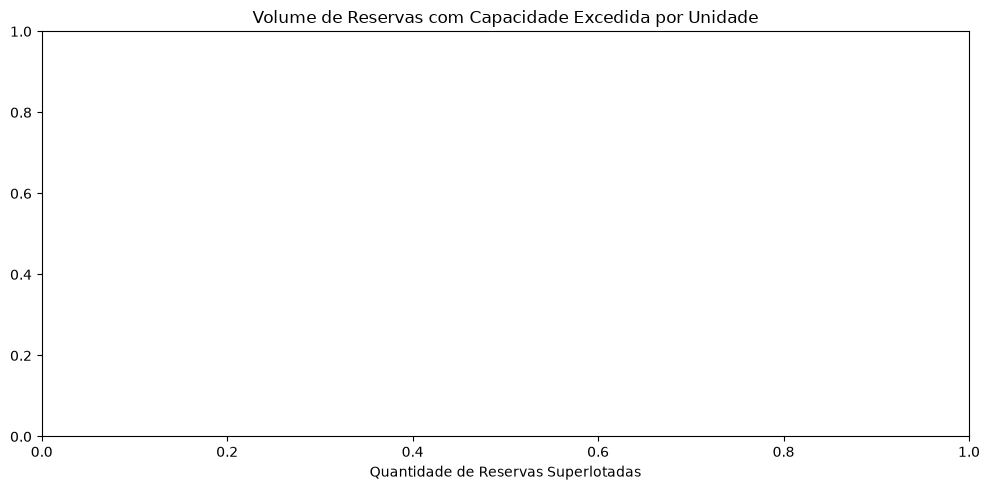

In [10]:
plt.figure(figsize=(10, 5))
sns.barplot(data=contagem_superlotacao, x='qtd_reservas_excedentes', y='nome_unidade', palette='Reds_r')
plt.title('Volume de Reservas com Capacidade Excedida por Unidade')
plt.xlabel('Quantidade de Reservas Superlotadas')
plt.ylabel('')
plt.tight_layout()
plt.show()

,Unidade,Diárias Vendidas,Capacidade Máxima (Diárias),Taxa de Ocupação (%)
3,NaraHoteis Santa Teresa,809,39690,2.04%
11,NaraHoteis Mangaratiba,808,44100,1.83%
8,NaraHoteis Friburgo,805,48510,1.66%
5,NaraHoteis Nova Iguaçu Park,772,48510,1.59%
7,NaraHoteis Teresópolis,745,52920,1.41%
6,NaraHoteis Petrópolis,790,61740,1.28%
9,NaraHoteis Paraty,826,66150,1.25%
0,NaraHoteis Ipanema,750,70560,1.06%
4,NaraHoteis Nova Iguaçu Centro,448,44100,1.02%
2,NaraHoteis Centro,519,52920,0.98%


C:\Users\Robert\AppData\Local\Temp\ipykernel_2176\819211583.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ocupacao, x='taxa_ocupacao_pct', y='nome_unidade', palette='Blues_r')


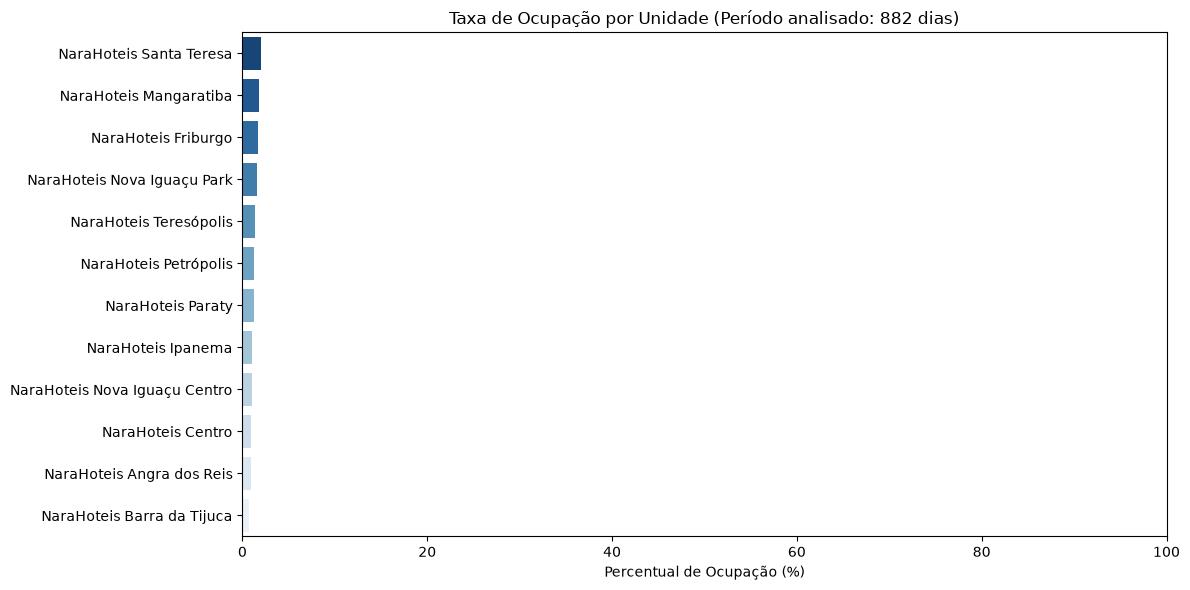

In [11]:

# 1. Carregando as bases necessárias para esta análise
df_reservas = pd.read_csv('reservas.csv', sep=';')
df_unidades = pd.read_csv('unidades.csv', sep=';')

# 2. Convertendo as colunas de data para calcularmos o período de operação
# Isso garante que o Python entenda os dados como datas para fazer matemática
df_reservas['data_checkin'] = pd.to_datetime(df_reservas['data_checkin'], errors='coerce')
df_reservas['data_checkout'] = pd.to_datetime(df_reservas['data_checkout'], errors='coerce')

# Descobrindo quantos dias de operação temos na base de dados
data_min = df_reservas['data_checkin'].min()
data_max = df_reservas['data_checkout'].max()
dias_operacao = (data_max - data_min).days

# Caso a base tenha apenas 1 dia, evitamos erro de divisão por zero
if dias_operacao == 0:
    dias_operacao = 1 

# 3. Calculando o Total de Diárias Vendidas por Unidade
diarias_vendidas = df_reservas.groupby('id_unidade')['qtd_diarias'].sum().reset_index()

# 4. Cruzando com a tabela de unidades para saber o total de quartos físicos disponíveis
df_ocupacao = diarias_vendidas.merge(df_unidades[['id_unidade', 'nome_unidade', 'num_quartos_total']], on='id_unidade')

# 5. Calculando a Taxa de Ocupação (%)
# A capacidade total de vendas = (Número de Quartos) * (Dias de Operação)
df_ocupacao['capacidade_total_diarias'] = df_ocupacao['num_quartos_total'] * dias_operacao

# Ocupação = (O que vendeu / O que poderia ter vendido) * 100
df_ocupacao['taxa_ocupacao_pct'] = (df_ocupacao['qtd_diarias'] / df_ocupacao['capacidade_total_diarias']) * 100

# Ordenando da maior ocupação para a menor
df_ocupacao = df_ocupacao.sort_values(by='taxa_ocupacao_pct', ascending=False)

# 6. Preparando os dados para exibição na Tabela
df_ocupacao_exibicao = df_ocupacao[['nome_unidade', 'qtd_diarias', 'capacidade_total_diarias', 'taxa_ocupacao_pct']].copy()
df_ocupacao_exibicao.columns = ['Unidade', 'Diárias Vendidas', 'Capacidade Máxima (Diárias)', 'Taxa de Ocupação (%)']
df_ocupacao_exibicao['Taxa de Ocupação (%)'] = df_ocupacao_exibicao['Taxa de Ocupação (%)'].apply(lambda x: f"{x:.2f}%")

# Exibindo a Tabela
display(df_ocupacao_exibicao)

# 7. Visualização Gráfica para o Relatório
plt.figure(figsize=(12, 6))
sns.barplot(data=df_ocupacao, x='taxa_ocupacao_pct', y='nome_unidade', palette='Blues_r')
plt.title(f'Taxa de Ocupação por Unidade (Período analisado: {dias_operacao} dias)')
plt.xlabel('Percentual de Ocupação (%)')
plt.ylabel('')
plt.xlim(0, 100) # O limite do gráfico vai de 0% a 100%
plt.tight_layout()
plt.show()

In [12]:
data_min = df_reservas['data_checkin'].min()
data_max = df_reservas['data_checkout'].max()
dias_operacao = (data_max - data_min).days

print(f"Primeiro Check-in da base: {data_min}")
print(f"Último Check-out da base: {data_max}")
print(f"Total de dias de operação calculados: {dias_operacao}")

Primeiro Check-in da base: 2023-01-01 00:00:00
Último Check-out da base: 2025-06-01 00:00:00
Total de dias de operação calculados: 882


In [13]:
import pandas as pd
from datetime import timedelta

# 1. Garantindo o formato de data e encontrando o último check-in da base
df_reservas['data_checkin'] = pd.to_datetime(df_reservas['data_checkin'], errors='coerce')
data_maxima = df_reservas['data_checkin'].max()

# 2. Definindo a data de corte para os últimos 90 dias (3 meses)
data_corte = data_maxima - timedelta(days=90)

# 3. Filtrando apenas as reservas recentes
reservas_recentes = df_reservas[df_reservas['data_checkin'] >= data_corte]

print(f"Analisando reservas de {data_corte.date()} até {data_maxima.date()}")
print(f"Total de reservas no período: {len(reservas_recentes)}\n")

# 4. Cruzando com a capacidade e unidades
df_capacidade_rec = reservas_recentes.merge(df_tipos_quarto[['id_tipo_quarto', 'capacidade_max']], on='id_tipo_quarto', how='left')
df_capacidade_rec = df_capacidade_rec.merge(df_unidades[['id_unidade', 'nome_unidade']], on='id_unidade', how='left')

# 5. Calculando a superlotação (hóspedes > capacidade)
df_capacidade_rec['superlotado'] = df_capacidade_rec['num_hospedes'] > df_capacidade_rec['capacidade_max']
casos_recentes = df_capacidade_rec[df_capacidade_rec['superlotado'] == True]

# 6. Exibindo os resultados (se houver)
if len(casos_recentes) > 0:
    display(casos_recentes[['id_reserva', 'nome_unidade', 'num_hospedes', 'capacidade_max']])
else:
    print("Nenhum caso de superlotação detectado nos últimos 3 meses.")

Analisando reservas de 2024-10-02 até 2024-12-31
Total de reservas no período: 276

Nenhum caso de superlotação detectado nos últimos 3 meses.


,Unidade,Diárias Vendidas,Ocupação (%)
3,NaraHoteis Santa Teresa,142,3.51%
9,NaraHoteis Paraty,127,1.88%
5,NaraHoteis Nova Iguaçu Park,111,2.24%


C:\Users\Robert\AppData\Local\Temp\ipykernel_2176\1142123864.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top3_unidades, x='qtd_diarias', y='nome_unidade', palette='mako')


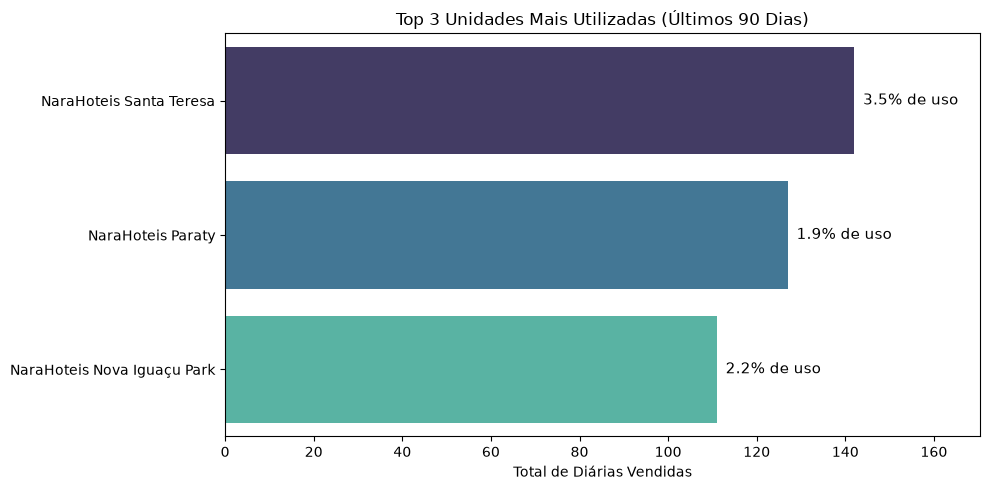

In [15]:



# 1. Filtro dos últimos 90 dias
df_reservas['data_checkin'] = pd.to_datetime(df_reservas['data_checkin'], errors='coerce')
data_maxima = df_reservas['data_checkin'].max()
data_corte = data_maxima - timedelta(days=90)
reservas_recentes = df_reservas[df_reservas['data_checkin'] >= data_corte].copy()

# 2. Total de diárias vendidas por unidade
uso_unidades = reservas_recentes.groupby('id_unidade')['qtd_diarias'].sum().reset_index()

# 3. Cruzamento com unidades para buscar o total de quartos
uso_unidades = uso_unidades.merge(df_unidades[['id_unidade', 'nome_unidade', 'num_quartos_total']], on='id_unidade')

# 4. Cálculo da Capacidade e Percentual de Uso (%)
# Capacidade = quartos disponíveis * 90 dias
uso_unidades['capacidade_trimestre'] = uso_unidades['num_quartos_total'] * 90
uso_unidades['ocupacao_pct'] = (uso_unidades['qtd_diarias'] / uso_unidades['capacidade_trimestre']) * 100

# 5. Selecionando as Top 3 mais utilizadas
top3_unidades = uso_unidades.sort_values(by='qtd_diarias', ascending=False).head(3)

# Exibindo a Tabela Resumo
df_tabela = top3_unidades[['nome_unidade', 'qtd_diarias', 'ocupacao_pct']].copy()
df_tabela.columns = ['Unidade', 'Diárias Vendidas', 'Ocupação (%)']
df_tabela['Ocupação (%)'] = df_tabela['Ocupação (%)'].apply(lambda x: f"{x:.2f}%")
display(df_tabela)

# 6. Visualização Gráfica
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=top3_unidades, x='qtd_diarias', y='nome_unidade', palette='mako')

# Adicionando o percentual no final de cada barra para facilitar a leitura
for p, pct in zip(ax.patches, top3_unidades['ocupacao_pct']):
    ax.annotate(f"{pct:.1f}% de uso", 
                (p.get_width() + 2, p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=11, color='black')

plt.title('Top 3 Unidades Mais Utilizadas (Últimos 90 Dias)')
plt.xlabel('Total de Diárias Vendidas')
plt.ylabel('')
plt.xlim(0, top3_unidades['qtd_diarias'].max() * 1.2) # Espaço extra para o texto caber
plt.tight_layout()
plt.show()

C:\Users\Robert\AppData\Local\Temp\ipykernel_2176\914752236.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top3_unidades, x='qtd_diarias', y='nome_unidade', palette='mako')


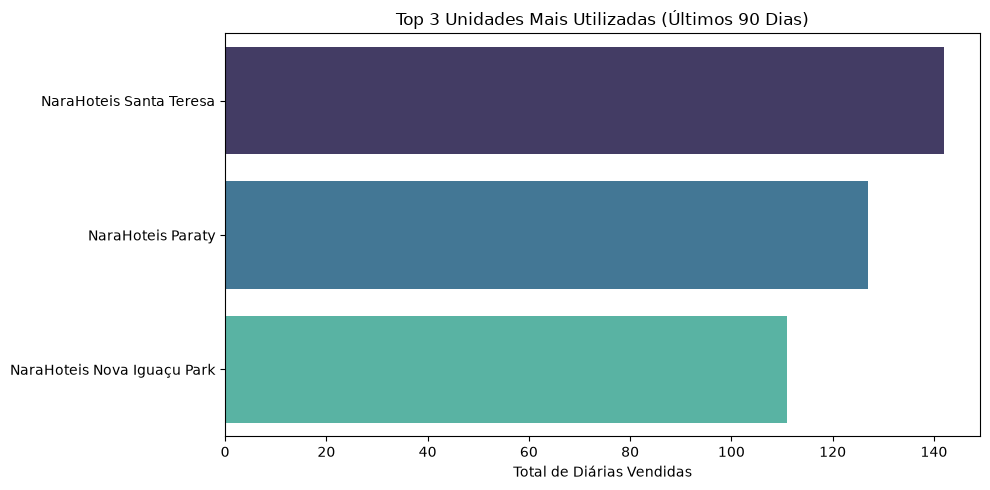

In [16]:


# 1. Preparação das datas e filtro dos últimos 3 meses
df_reservas['data_checkin'] = pd.to_datetime(df_reservas['data_checkin'], errors='coerce')
data_maxima = df_reservas['data_checkin'].max()
data_corte = data_maxima - timedelta(days=90)
reservas_recentes = df_reservas[df_reservas['data_checkin'] >= data_corte].copy()

# 2. Calculando o uso real (Soma de diárias vendidas) por unidade no período
uso_unidades = reservas_recentes.groupby('id_unidade')['qtd_diarias'].sum().reset_index()

# 3. Cruzando com os nomes das unidades
uso_unidades = uso_unidades.merge(df_unidades[['id_unidade', 'nome_unidade']], on='id_unidade')

# 4. Selecionando apenas as 3 unidades mais utilizadas (Top 3)
top3_unidades = uso_unidades.sort_values(by='qtd_diarias', ascending=False).head(3)

# 5. Gerando a visualização gráfica
plt.figure(figsize=(10, 5))
sns.barplot(data=top3_unidades, x='qtd_diarias', y='nome_unidade', palette='mako')
plt.title('Top 3 Unidades Mais Utilizadas (Últimos 90 Dias)')
plt.xlabel('Total de Diárias Vendidas')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [17]:
import pandas as pd

# 1. Selecionando apenas as colunas necessárias da dimensão de unidades
capacidade_mensal = df_unidades[['nome_unidade', 'num_quartos_total']].copy()

# 2. Lógica de Negócio: Capacidade máxima mensal (100% de ocupação em um mês de 30 dias)
capacidade_mensal['capacidade_100pct_mes'] = capacidade_mensal['num_quartos_total'] * 30

# 3. Ordenando da maior estrutura (mais quartos) para a menor
capacidade_mensal = capacidade_mensal.sort_values(by='capacidade_100pct_mes', ascending=False)

# Formatando a coluna para facilitar a leitura
capacidade_mensal['Capacidade Mensal (Diárias)'] = capacidade_mensal['capacidade_100pct_mes'].apply(lambda x: f"{x:,.0f}".replace(',', '.'))
df_exibicao_capacidade = capacidade_mensal[['nome_unidade', 'num_quartos_total', 'Capacidade Mensal (Diárias)']]
df_exibicao_capacidade.columns = ['Unidade', 'Total de Quartos', 'Diárias Equivalentes a 100% (Mês)']

display(df_exibicao_capacidade)


,Unidade,Total de Quartos,Diárias Equivalentes a 100% (Mês)
1,NaraHoteis Barra da Tijuca,120,3.600
10,NaraHoteis Angra dos Reis,90,2.700
0,NaraHoteis Ipanema,80,2.400
9,NaraHoteis Paraty,75,2.250
6,NaraHoteis Petrópolis,70,2.100
2,NaraHoteis Centro,60,1.800
7,NaraHoteis Teresópolis,60,1.800
8,NaraHoteis Friburgo,55,1.650
5,NaraHoteis Nova Iguaçu Park,55,1.650
11,NaraHoteis Mangaratiba,50,1.500


In [20]:
# 1. Diagnóstico: Verificando os nomes exatos das unidades disponíveis na base
print("Unidades disponíveis na base:")
print(df_unidades['nome_unidade'].unique())

# 2. Diagnóstico: Verificando quais anos realmente existem nas reservas
df_reservas['data_checkin'] = pd.to_datetime(df_reservas['data_checkin'], errors='coerce')
print("\nAnos presentes na base de reservas:")
print(df_reservas['data_checkin'].dt.year.dropna().unique())

Unidades disponíveis na base:
<StringArray>
[           'NaraHoteis Ipanema',    'NaraHoteis Barra da Tijuca',
             'NaraHoteis Centro',       'NaraHoteis Santa Teresa',
 'NaraHoteis Nova Iguaçu Centro',   'NaraHoteis Nova Iguaçu Park',
         'NaraHoteis Petrópolis',        'NaraHoteis Teresópolis',
           'NaraHoteis Friburgo',             'NaraHoteis Paraty',
     'NaraHoteis Angra dos Reis',        'NaraHoteis Mangaratiba',
 'NaraHoteis Copacabana Premium']
Length: 13, dtype: str

Anos presentes na base de reservas:
[2024 2023]


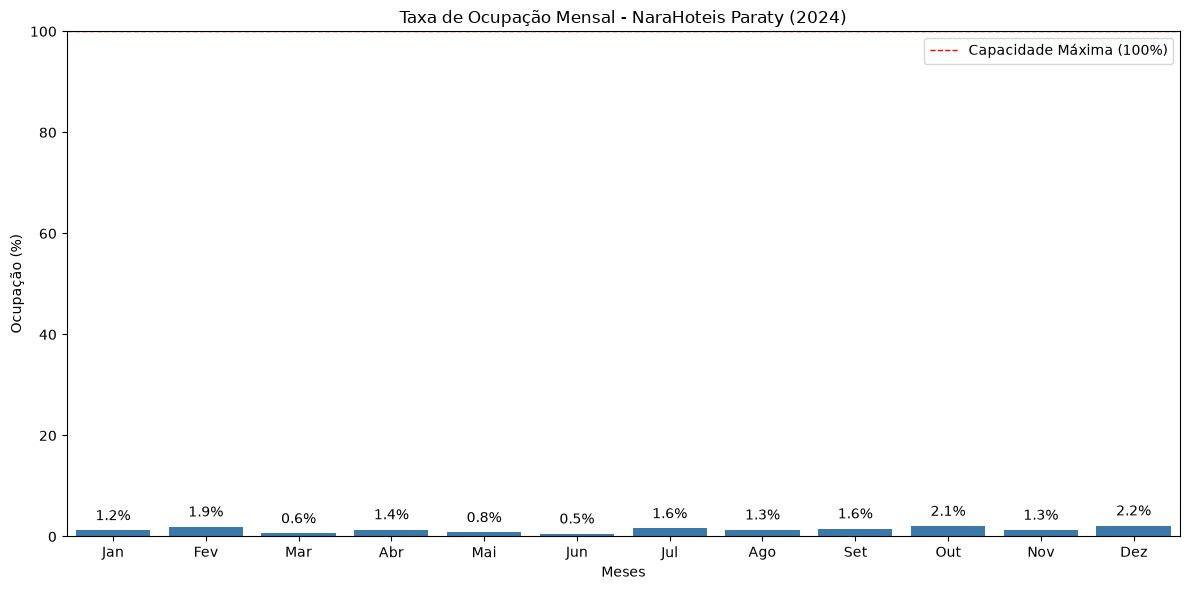

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

# 1. Preparação das datas e extração de Mês/Ano
df_reservas['data_checkin'] = pd.to_datetime(df_reservas['data_checkin'], errors='coerce')

# 2. Definindo o ano correto descoberto no diagnóstico (2024)
ano_analise = 2024
df_ano = df_reservas[df_reservas['data_checkin'].dt.year == ano_analise].copy()
df_ano['mes'] = df_ano['data_checkin'].dt.month

# 3. Agrupando as diárias vendidas por unidade e por mês
uso_mensal = df_ano.groupby(['id_unidade', 'mes'])['qtd_diarias'].sum().reset_index()
uso_mensal = uso_mensal.merge(df_unidades[['id_unidade', 'nome_unidade', 'num_quartos_total']], on='id_unidade')

# 4. Cálculo Dinâmico de Capacidade (considerando meses de 28, 30 ou 31 dias)
uso_mensal['dias_no_mes'] = uso_mensal['mes'].apply(lambda m: calendar.monthrange(ano_analise, m)[1])
uso_mensal['capacidade_max_mes'] = uso_mensal['num_quartos_total'] * uso_mensal['dias_no_mes']

# 5. Cálculo Final da Taxa de Ocupação (%)
uso_mensal['ocupacao_pct'] = (uso_mensal['qtd_diarias'] / uso_mensal['capacidade_max_mes']) * 100

# 6. Seleção da Unidade para o Gráfico (Utilize um dos nomes exatos que apareceu no print)
unidade_alvo = 'NaraHoteis Paraty'  # Exemplo de unidade válida
dados_grafico = uso_mensal[uso_mensal['nome_unidade'] == unidade_alvo].copy()

# Mapeando os números dos meses para os nomes para melhor leitura
meses_nomes = {1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun', 7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov', 12:'Dez'}
dados_grafico['nome_mes'] = dados_grafico['mes'].map(meses_nomes)

# 7. Visualização Gráfica Mensal
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=dados_grafico, x='nome_mes', y='ocupacao_pct', color='#2b7bba')

# Adicionando os rótulos de porcentagem em cima de cada barra
for p, pct in zip(ax.patches, dados_grafico['ocupacao_pct']):
    ax.annotate(f"{pct:.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.title(f'Taxa de Ocupação Mensal - {unidade_alvo} ({ano_analise})')
plt.xlabel('Meses')
plt.ylabel('Ocupação (%)')
plt.ylim(0, max(100, dados_grafico['ocupacao_pct'].max() + 15)) 
plt.axhline(100, color='red', linestyle='--', linewidth=1, label='Capacidade Máxima (100%)')
plt.legend()
plt.tight_layout()
plt.show()